In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/1/PBMC1_clustering.h5ad"

adata = sc.read(dir)

In [3]:
adata

AnnData object with n_obs × n_vars = 54057 × 19936
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gend

In [4]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 54063 × 19944
  var:	'n_cells'
  2 modalities
    rna:	54057 x 19936
      obs:	'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	6 x 8
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

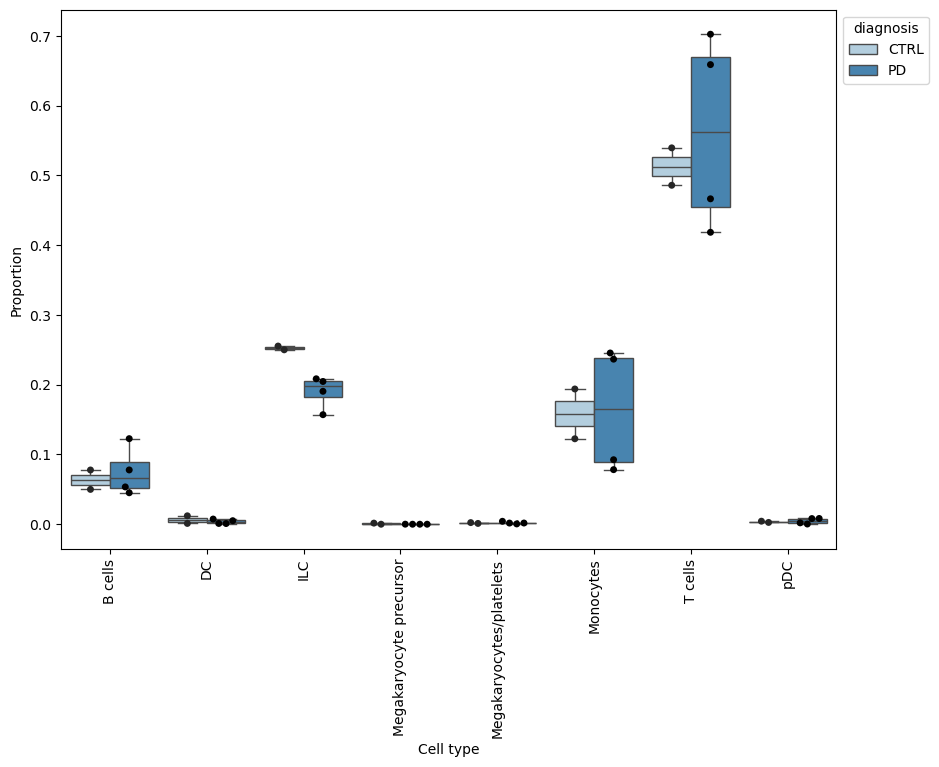

In [5]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"color": "red"},
)
plt.show()

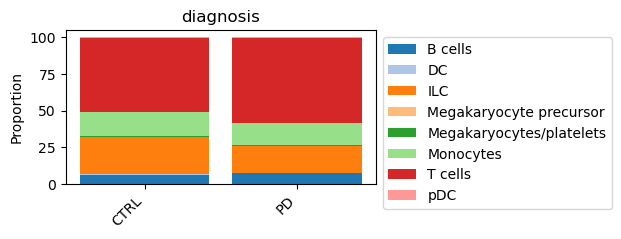

In [6]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [7]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'PD'], dtype='object')

In [8]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [00:18<00:00, 594.93it/s, 63 steps of size 6.39e-02. acc. prob=0.73]


In [9]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.366,0.492,0.149,0.4545,635.784544,0.0
DC,0.0,-0.693,0.549,0.217,0.4882,70.025519,0.0
ILC,0.0,-0.577,0.170,0.174,0.5438,2022.035059,0.0
Megakaryocyte precursor,0.0,-0.709,0.591,0.236,0.4951,24.924711,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,53.349240,0.0
Monocytes,0.0,-0.424,0.286,0.125,0.4571,1366.297408,0.0
T cells,0.0,-0.244,0.349,0.104,0.4276,4768.846535,0.0
pDC,0.0,-0.680,0.571,0.227,0.5070,68.570317,0.0


In [ ]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). Likely underpowered to observe any differences (6 samples)

In [11]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
sccoda_model.credible_effects(sccoda_data, modality_key="coda")


Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocyte precursor     False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

In [12]:
# return to default FDR threshold of 0.05 for downstream analyses

sccoda_model.set_fdr(sccoda_data, 0.05)
sccoda_model.credible_effects(sccoda_data, modality_key="coda")

Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocyte precursor     False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

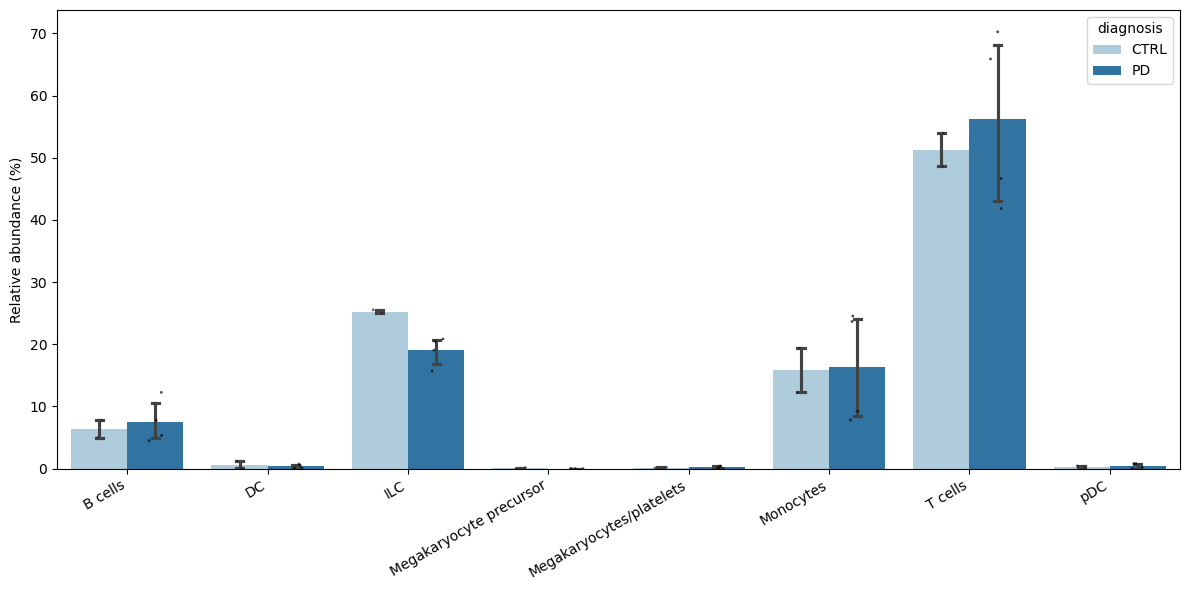

In [13]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()

# should i add a ns annotation to indicate non-significant differences?

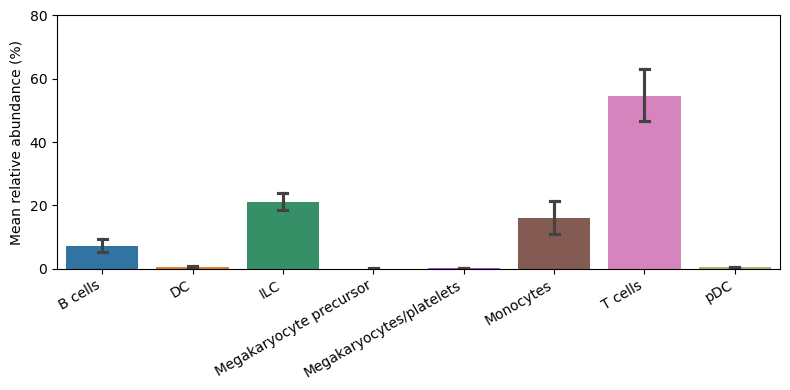

In [14]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  # was "cell_type" — column doesn't exist yet
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

In [15]:
df

celltypist_cell_label_coarse,B cells,DC,ILC,Megakaryocyte precursor,Megakaryocytes/platelets,Monocytes,T cells,pDC,diagnosis
scCODA_sample_id,,,,,,,,,
1,4.992068,1.205711,25.002644,0.158646,0.232681,19.386568,48.588049,0.433633,CTRL
2,7.774205,0.114327,25.537692,0.007145,0.114327,12.247231,53.947839,0.257235,CTRL
3,4.509063,0.098187,15.702417,0.007553,0.166163,9.244713,70.241692,0.030211,PD
4,5.346474,0.110872,20.461965,0.006160,0.172467,7.822605,65.882353,0.197105,PD
5,12.265552,0.506023,20.845938,0.005500,0.044002,23.662065,41.845883,0.825037,PD
6,7.780960,0.740379,19.054271,0.006985,0.419082,24.544248,46.643850,0.810226,PD


In [16]:
# recalculate relative abundance just for controls samples

ctrl_data = adata[adata.obs["diagnosis"] == "CTRL"]

ctrl_plot_df = (
    ctrl_data.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

ctrl_plot_df

,sample,celltypist_cell_label_coarse,count,rel_abundance
0,1,B cells,472,4.992068
1,1,DC,114,1.205711
2,1,ILC,2364,25.002644
3,1,Megakaryocyte precursor,15,0.158646
4,1,Megakaryocytes/platelets,22,0.232681
5,1,Monocytes,1833,19.386568
6,1,T cells,4594,48.588049
7,1,pDC,41,0.433633
8,2,B cells,544,7.774761
9,2,DC,8,0.114335


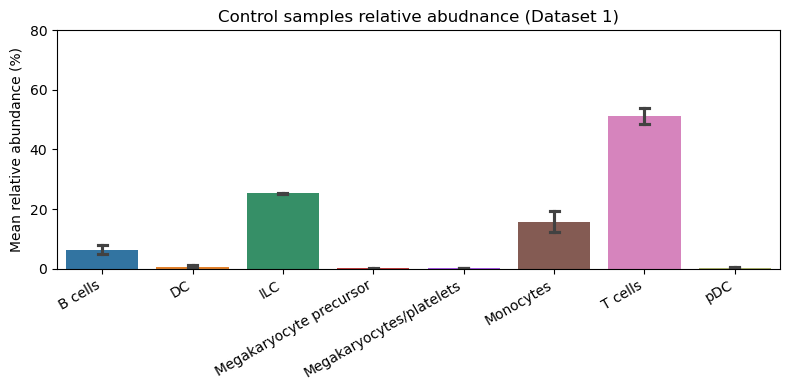

In [17]:
# plot just the control samples:

plt.figure(figsize=(8, 4))
sns.barplot(
    data=ctrl_plot_df,
    x="celltypist_cell_label_coarse",
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.title("Control samples relative abudnance (Dataset 1)")
plt.tight_layout()
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.show()


In [18]:
# Compare numerical differences between all samples and control-only samples

# Calculate mean relative abundance by cell type
all_samples_mean = plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()
ctrl_only_mean = ctrl_plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "All samples (%)": all_samples_mean,
    "Control only (%)": ctrl_only_mean,
})
comparison_df["Difference (%)"] = comparison_df["All samples (%)"] - comparison_df["Control only (%)"]
comparison_df = comparison_df.sort_values("Difference (%)", ascending=False)

print("Cell type composition comparison:\n")
print(comparison_df.round(2))


Cell type composition comparison:

                              All samples (%)  Control only (%)  \
celltypist_cell_label_coarse                                      
T cells                                 54.53             51.27   
B cells                                  7.11              6.38   
Monocytes                               16.15             15.82   
pDC                                      0.43              0.35   
Megakaryocytes/platelets                 0.19              0.17   
Megakaryocyte precursor                  0.03              0.08   
DC                                       0.46              0.66   
ILC                                     21.10             25.27   

                              Difference (%)  
celltypist_cell_label_coarse                  
T cells                                 3.26  
B cells                                 0.73  
Monocytes                               0.33  
pDC                                     0.08  
Megakaryocyt

In [19]:
# redo composition analysis with fine annotations 

sccoda_model2 = pt.tl.Sccoda()
sccoda_data2 = sccoda_model2.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_fine",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data2

MuData object with n_obs × n_vars = 54063 × 19953
  var:	'n_cells'
  2 modalities
    rna:	54057 x 19936
      obs:	'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	6 x 17
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

In [20]:
# run scCODA model
sccoda_data2 = sccoda_model2.prepare(
    sccoda_data2,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model2.run_nuts(sccoda_data2, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [00:25<00:00, 424.27it/s, 63 steps of size 5.87e-02. acc. prob=0.77]


In [21]:
sccoda_data2["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,0.0,-0.380,0.428,0.153,0.5221,49.330752,0.0
CD16+ NK cells,0.0,-0.484,0.123,0.149,0.5707,1849.272602,0.0
Classical monocytes,0.0,-0.344,0.287,0.111,0.4808,1028.182184,0.0
DC2,0.0,-0.445,0.382,0.150,0.5111,57.256871,0.0
MAIT cells,0.0,-0.422,0.374,0.140,0.5091,170.638563,0.0
Megakaryocyte precursor,0.0,-0.436,0.442,0.161,0.5053,18.147769,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,42.929003,0.0
Memory B cells,0.0,-0.454,0.347,0.148,0.5079,220.422829,0.0
Naive B cells,0.0,-0.265,0.424,0.131,0.4994,398.038069,0.0


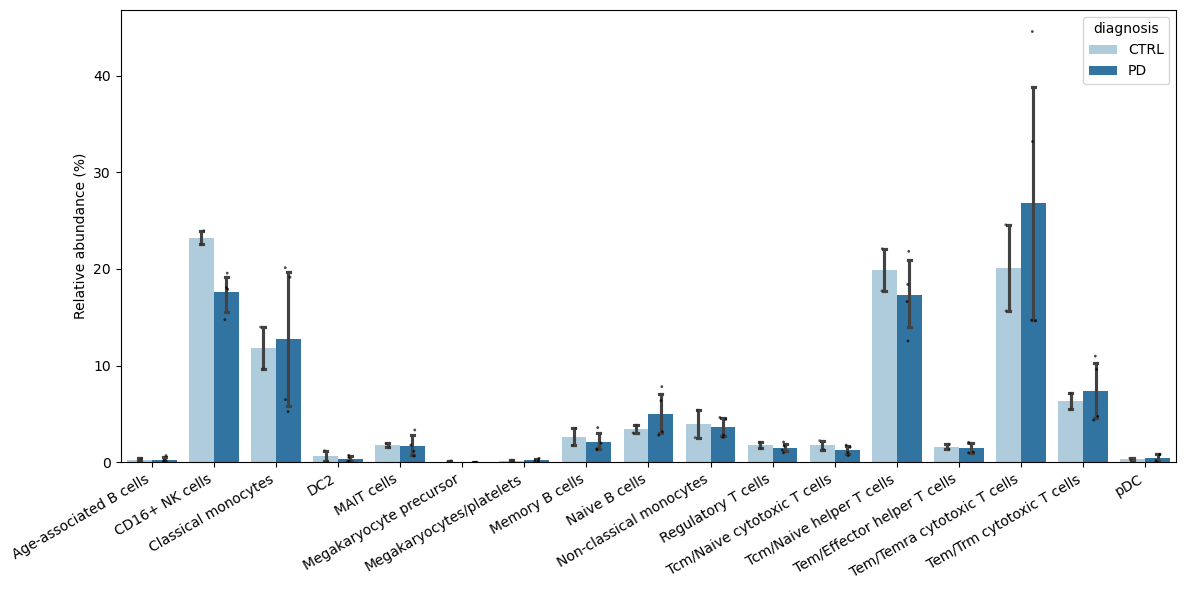

In [22]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data2["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [23]:
sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocyte precursor        False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                            False
Name: Final Parameter, dtype: bool

In [24]:
#RERUN

sccoda_model2.set_fdr(sccoda_data2, 0.2)
sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocyte precursor        False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                            False
Name: Final Parameter, dtype: bool

In [25]:
sccoda_model.set_fdr(sccoda_data, 0.05)

In [26]:
# now try sccoda with filtering out rare cell types (those with mean relative abundance < 1%)

cell_type_col = "celltypist_cell_label_fine"
sample_col    = "sample"
min_mean_prop = 0.01   # 1%

# Per-sample cell-type counts -> per-sample proportions -> mean across samples
counts = (
    adata.obs
    .groupby([sample_col, cell_type_col])
    .size()
    .unstack(fill_value=0)
)
props      = counts.div(counts.sum(axis=1), axis=0)
mean_props = props.mean(axis=0).sort_values(ascending=False)

keep    = mean_props[mean_props >= min_mean_prop].index.tolist()
dropped = mean_props[mean_props <  min_mean_prop].index.tolist()

print(f"Keeping {len(keep)} cell types (mean per-sample proportion ≥ {min_mean_prop:.0%}):")
print(mean_props.loc[keep].round(4).to_string())
print(f"\nDropping {len(dropped)} rare cell types:")
print(mean_props.loc[dropped].round(4).to_string())

# Filter AnnData to retained cell types
adata_filt = adata[adata.obs[cell_type_col].isin(keep)].copy()
# (optional) drop unused category levels so scCODA doesn't see empty columns
adata_filt.obs[cell_type_col] = adata_filt.obs[cell_type_col].astype(str).astype("category")

Keeping 12 cell types (mean per-sample proportion ≥ 1%):
celltypist_cell_label_fine
Tem/Temra cytotoxic T cells    0.2455
CD16+ NK cells                 0.1946
Tcm/Naive helper T cells       0.1821
Classical monocytes            0.1245
Tem/Trm cytotoxic T cells      0.0706
Naive B cells                  0.0452
Non-classical monocytes        0.0374
Memory B cells                 0.0227
MAIT cells                     0.0174
Regulatory T cells             0.0161
Tem/Effector helper T cells    0.0155
Tcm/Naive cytotoxic T cells    0.0144

Dropping 5 rare cell types:
celltypist_cell_label_fine
DC2                         0.0046
pDC                         0.0043
Age-associated B cells      0.0029
Megakaryocytes/platelets    0.0019
Megakaryocyte precursor     0.0003


In [27]:
sccoda_model = pt.tl.Sccoda()
sccoda_data_filt = sccoda_model.load(
    adata_filt,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier=cell_type_col,
    sample_identifier=sample_col,
    covariate_obs=["diagnosis"],
)

sccoda_data_filt = sccoda_model.prepare(
    sccoda_data_filt,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic",
)
sccoda_model.run_nuts(sccoda_data_filt, modality_key="coda", rng_key=1234)

# effects
sccoda_data_filt["coda"].varm["effect_df_diagnosis[T.PD]"]

# FDR 0.2 for sensitivity
sccoda_model.set_fdr(sccoda_data_filt, 0.2)
print(sccoda_model.credible_effects(sccoda_data_filt, modality_key="coda"))

# back to 0.05
sccoda_model.set_fdr(sccoda_data_filt, 0.05)
print(sccoda_model.credible_effects(sccoda_data_filt, modality_key="coda"))

sample: 100%|██████████| 11000/11000 [00:22<00:00, 497.15it/s, 63 steps of size 6.23e-02. acc. prob=0.76]


Covariate        Cell Type                  
diagnosis[T.PD]  CD16+ NK cells                 False
                 Classical monocytes            False
                 MAIT cells                     False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
Name: Final Parameter, dtype: bool
Covariate        Cell Type                  
diagnosis[T.PD]  CD16+ NK cells                 False
                 Classical monocytes            False
                 MAIT cells                     False
                 Memory B cells                 False
           

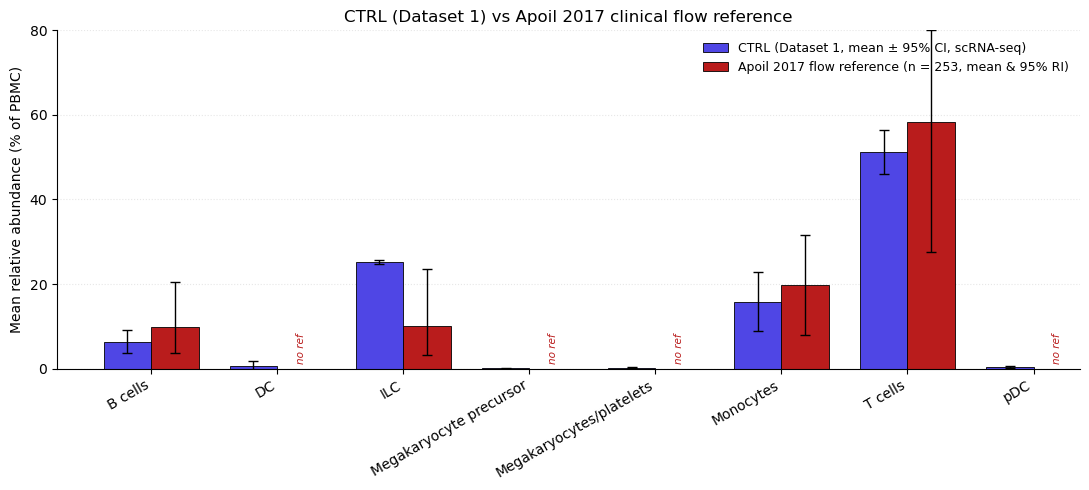

In [29]:

# ---------- Apoil 2017 reference, scaled to % of PBMC ----------
# PBMC denominator: Apoil lymph (2012/µL) + clinical mono ref (500/µL)
# + Autissier DCs (15/µL) ≈ 2527 cells/µL
PBMC_MEAN = 2012 + 500 + 15

# cluster, mean_count, lo_count, hi_count
apoil_rows = [
    ("T cells",                   1473,  700, 2508),
    ("B cells",                    247,   92,  515),
    ("ILC",                        253,   82,  594),
    ("Monocytes",                  500,  200,  800),   # clinical reference, not Apoil
    ("Plasma cells",               3.2,  0.5, 12.4),   # Apoil plasmablasts × B count
    ("DC",                        None, None, None),   # not covered
    ("pDC",                       None, None, None),
    ("Megakaryocytes/platelets",  None, None, None),
]
apoil_ref = pd.DataFrame(
    apoil_rows,
    columns=["celltypist_cell_label_coarse", "mean_count", "lo_count", "hi_count"],
)
apoil_ref["apoil_mean"] = apoil_ref["mean_count"] / PBMC_MEAN * 100
apoil_ref["apoil_lo"]   = apoil_ref["lo_count"]   / PBMC_MEAN * 100
apoil_ref["apoil_hi"]   = apoil_ref["hi_count"]   / PBMC_MEAN * 100
# cap the T-cell upper bound at ~80 so the y axis doesn't break
apoil_ref.loc[apoil_ref["celltypist_cell_label_coarse"] == "T cells", "apoil_hi"] = 80.0

# ---------- aggregate your CTRL: mean + 95% CI per cluster ----------
ctrl_stats = (
    ctrl_plot_df
    .groupby("celltypist_cell_label_coarse", observed=True)["rel_abundance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
ctrl_stats["ci95"] = 1.96 * ctrl_stats["std"] / np.sqrt(ctrl_stats["count"])

# merge, keeping CTRL order as the x-axis
df = (
    ctrl_stats
    .merge(apoil_ref, on="celltypist_cell_label_coarse", how="left")
    .rename(columns={"mean": "ctrl_mean"})
)

# ---------- paired bar plot ----------
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.38

# your CTRL (blue) — mean ± 95% CI
ax.bar(
    x - w/2, df["ctrl_mean"], w,
    yerr=df["ci95"], capsize=3.5,
    color="#4f46e5", edgecolor="black", linewidth=0.6,
    label="CTRL (Dataset 1, mean ± 95% CI, scRNA-seq)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# Apoil reference (red) — mean with asymmetric 95% RI
err_lo = (df["apoil_mean"] - df["apoil_lo"]).astype(float)
err_hi = (df["apoil_hi"]   - df["apoil_mean"]).astype(float)
ax.bar(
    x + w/2, df["apoil_mean"], w,
    yerr=[err_lo, err_hi], capsize=3.5,
    color="#b91c1c", edgecolor="black", linewidth=0.6,
    label="Apoil 2017 flow reference (n = 253, mean & 95% RI)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# mark clusters with no reference
for i, row in df.iterrows():
    if pd.isna(row["apoil_mean"]):
        ax.text(i + w/2, 1.2, "no ref", ha="center", va="bottom",
                rotation=90, color="#b91c1c", fontsize=7.5, style="italic")

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(df["celltypist_cell_label_coarse"], rotation=30, ha="right")
ax.set_ylabel("Mean relative abundance (% of PBMC)")
ax.set_xlabel("")
ax.set_title("CTRL (Dataset 1) vs Apoil 2017 clinical flow reference")
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 20))
ax.grid(axis="y", linestyle=":", alpha=0.3)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Trying scanpro for compositional analysis

from scanpro.scanpro import scanpro

In [ ]:
out = scanpro(adata, samples_col='sample', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis') # default transformation is logit (can also specify transformation='arcsin')

out.results

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


,baseline_props,mean_props_CTRL,mean_props_PD,prop_ratio,t_statistics,p_values,adjusted_p_values
clusters,,,,,,,
B cells,0.068798,0.063834,0.074759,0.853866,-0.284321,0.786685,0.918073
DC,0.004495,0.006600,0.003639,1.813815,0.410436,0.697174,0.918073
ILC,0.206264,0.252711,0.190171,1.328862,1.386030,0.219930,0.918073
Megakaryocyte precursor,0.000296,0.000793,0.000019,42.009519,1.147301,0.299250,0.918073
Megakaryocytes/platelets,0.001850,0.001735,0.002004,0.865639,0.107733,0.918073,0.918073
Monocytes,0.156446,0.158173,0.163193,0.969242,0.118638,0.909825,0.918073
T cells,0.557930,0.512699,0.561558,0.912993,-0.469385,0.657031,0.918073
pDC,0.003922,0.003454,0.004657,0.741814,0.270623,0.796663,0.918073


In [43]:
out.props

celltypist_cell_label_coarse,B cells,DC,ILC,Megakaryocyte precursor,Megakaryocytes/platelets,Monocytes,T cells,pDC
sample,,,,,,,,
1,0.049921,0.012057,0.250026,0.001586,0.002327,0.193866,0.485880,0.004336
2,0.077748,0.001143,0.255395,0.000000,0.001143,0.122481,0.539517,0.002573
3,0.045091,0.000982,0.157024,0.000076,0.001662,0.092447,0.702417,0.000302
4,0.053468,0.001109,0.204632,0.000000,0.001725,0.078231,0.658864,0.001971
5,0.122662,0.005061,0.208471,0.000000,0.000440,0.236634,0.418482,0.008251
6,0.077815,0.007404,0.190556,0.000000,0.004191,0.245460,0.466471,0.008103


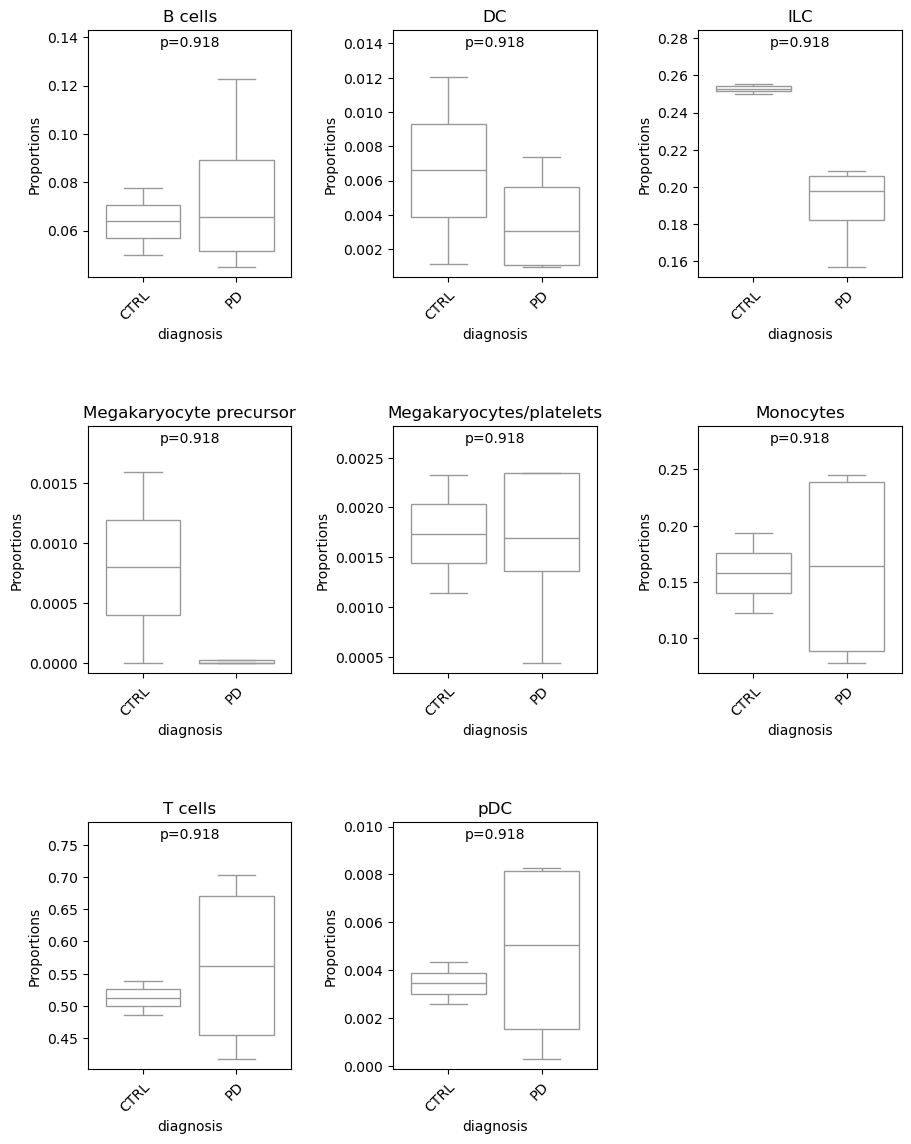

In [40]:
out.plot(kind='boxplot')


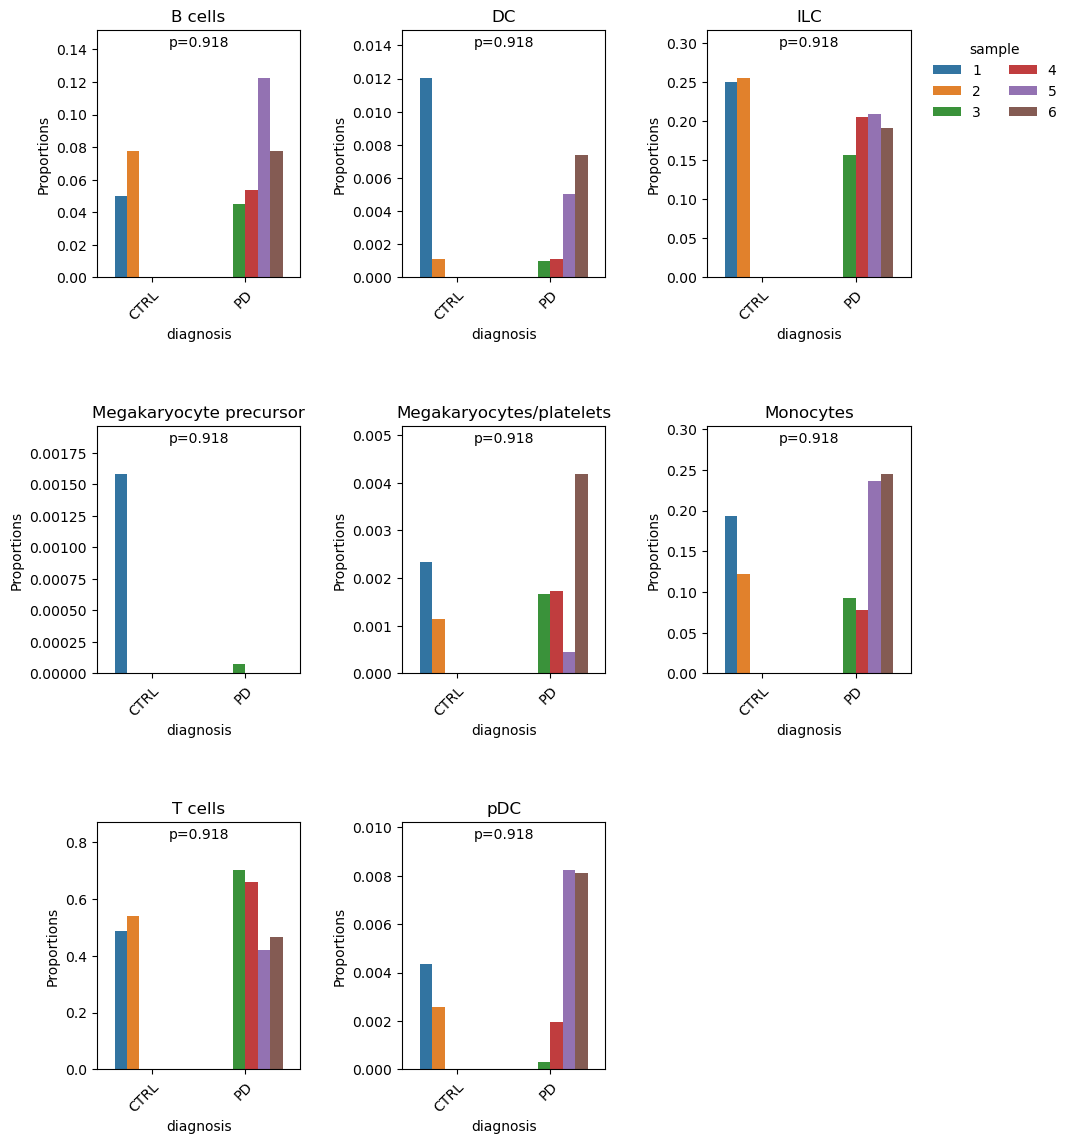

In [41]:
out.plot(kind='barplot')
